In [1]:
# ================================================
# ML Modelling
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Load clean data
print("Loading clean data...")
df = pd.read_csv(r'C:\Users\namey\credit-risk-analysis\data\processed\clean_data.csv')
print(f"✅ Shape: {df.shape}")
print(f"Default rate: {df['TARGET'].mean()*100:.2f}%")

Loading clean data...
✅ Shape: (307511, 87)
Default rate: 8.07%


In [2]:
# ================================================
# Prepare features
# ================================================

# Drop columns not useful for modelling
drop_cols = [
    'SK_ID_CURR',       # ID column
    'AGE_GROUP',        # replaced by AGE_YEARS
    'LOAN_INCOME_RATIO_CAT'  # categorical version of DEBT_TO_INCOME
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# Encode categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Encoding {len(cat_cols)} categorical columns: {cat_cols}")

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Split features and target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(f"\n Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Class balance:\n{y.value_counts()}")

Encoding 12 categorical columns: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

 Features shape: (307511, 83)
Target shape: (307511,)
Class balance:
TARGET
0    282686
1     24825
Name: count, dtype: int64


In [3]:
# ================================================
# Train/Test Split
# ================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # ensures same default rate in both splits
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"\nDefault rate in train: {y_train.mean()*100:.2f}%")
print(f"Default rate in test:  {y_test.mean()*100:.2f}%")

Training set:  (246008, 83)
Test set:      (61503, 83)

Default rate in train: 8.07%
Default rate in test:  8.07%


In [4]:
# ================================================
# Train XGBoost Model
# ================================================

# Handle class imbalance — there are 11x more repaid than defaulted
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio: {scale_pos_weight:.1f}x")
print("Training XGBoost... (2-3 mins, please wait)")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles imbalance
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=20,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\n XGBoost training complete!")

Class imbalance ratio: 11.4x
Training XGBoost... (2-3 mins, please wait)
[0]	validation_0-auc:0.71698
[50]	validation_0-auc:0.74663
[100]	validation_0-auc:0.75355
[150]	validation_0-auc:0.75550
[200]	validation_0-auc:0.75645
[250]	validation_0-auc:0.75696
[299]	validation_0-auc:0.75756

 XGBoost training complete!


In [5]:
# ================================================
# Train Random Forest & Logistic Regression
# ================================================

# Random Forest
print("Training Random Forest... (2-3 mins)")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("Random Forest done!")

# Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr_model.fit(X_train, y_train)
print("Logistic Regression done!")

Training Random Forest... (2-3 mins)
Random Forest done!
Training Logistic Regression...
Logistic Regression done!


In [6]:
# ================================================
# Model Evaluation
# ================================================

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

print("=" * 50)
print("MODEL COMPARISON — AUC SCORES")
print("=" * 50)

results = {}
for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = {'auc': auc, 'proba': y_pred_proba}
    print(f"{name:25s} → AUC: {auc:.4f}")

print("=" * 50)
best_model = max(results, key=lambda x: results[x]['auc'])
print(f"\n Best model: {best_model} (AUC: {results[best_model]['auc']:.4f})")

MODEL COMPARISON — AUC SCORES
Logistic Regression       → AUC: 0.6173
Random Forest             → AUC: 0.7431
XGBoost                   → AUC: 0.7576

 Best model: XGBoost (AUC: 0.7576)


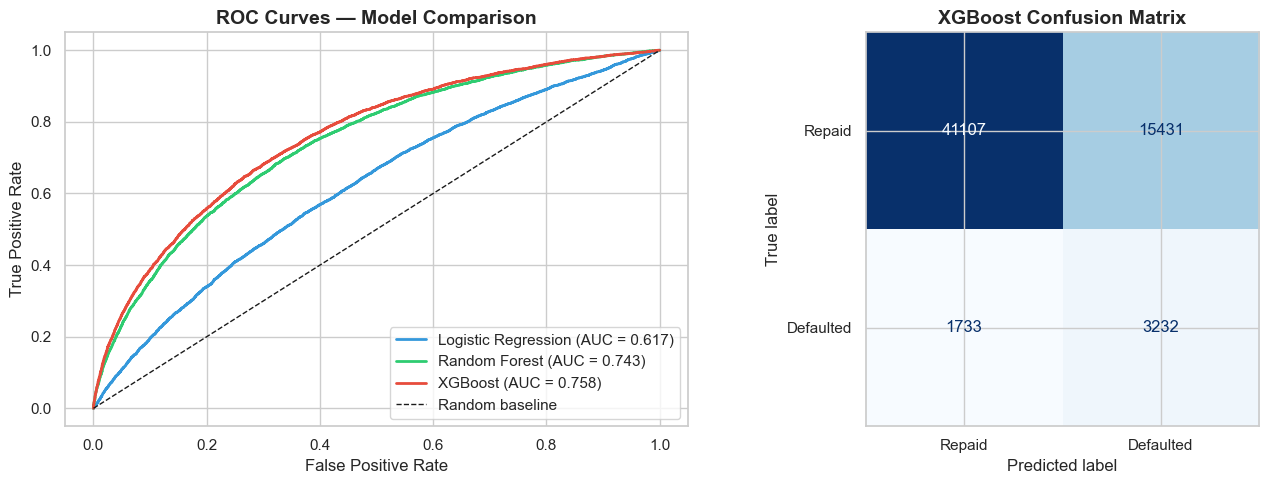

ROC curves and confusion matrix saved!


In [7]:
# ================================================
# Visualizations
# ================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves for all models
colors = ['#3498db', '#2ecc71', '#e74c3c']
for (name, result), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, result['proba'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{name} (AUC = {result['auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')

# Confusion Matrix for XGBoost
y_pred_xgb = xgb_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Repaid', 'Defaulted'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\06_roc_confusion.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves and confusion matrix saved!")

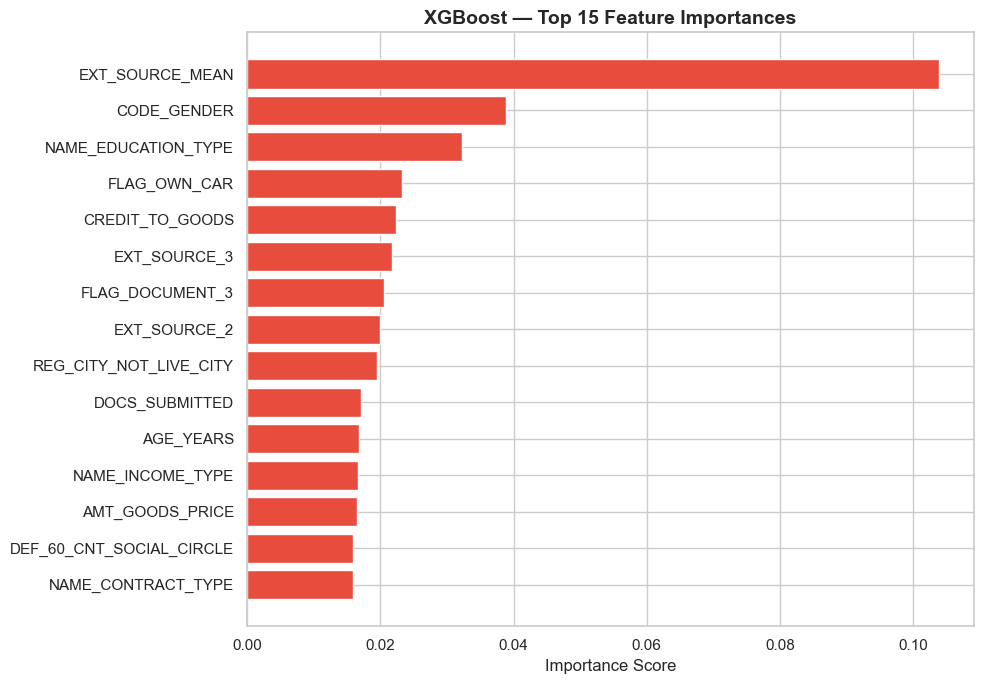

Feature importance plot saved!

Top 10 most important features:
  EXT_SOURCE_MEAN                     0.1040
  CODE_GENDER                         0.0388
  NAME_EDUCATION_TYPE                 0.0323
  FLAG_OWN_CAR                        0.0232
  CREDIT_TO_GOODS                     0.0224
  EXT_SOURCE_3                        0.0218
  FLAG_DOCUMENT_3                     0.0205
  EXT_SOURCE_2                        0.0199
  REG_CITY_NOT_LIVE_CITY              0.0195
  DOCS_SUBMITTED                      0.0171


In [8]:
# ================================================
# Feature Importance
# ================================================

# Get top 15 important features
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True).tail(15)

plt.figure(figsize=(10, 7))
plt.barh(importance_df['feature'], importance_df['importance'],
         color='#e74c3c', edgecolor='white')
plt.title('XGBoost — Top 15 Feature Importances',
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r'C:\Users\namey\credit-risk-analysis\reports\screenshots\07_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved!")

# Print top 10
print("\nTop 10 most important features:")
for _, row in importance_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}")